In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import plotly.graph_objects as go
import gc

# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from methods_2 import evaluate_metrics


## Training

Example of training and testing

In [2]:
# Load the MAT file
mat_file = sio.loadmat('100307.REST1.LR.SchaeferS.ptseries.mat')
 
print(mat_file.keys())

dict_keys(['__header__', '__version__', '__globals__', 'tseries'])


In [3]:
data = torch.from_numpy(mat_file['tseries']).float()

In [4]:
print(data.dtype)

torch.float32


In [5]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [6]:
# PARAMETERS

N_NEURONS = 200
INPUT_DIM = data.shape[0] # equals to output dim

LR = 0.01
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [7]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [8]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius=0.9,
    scale = 0.1
)


In [9]:
# Generate Torch datasets
train_ds, valid_ds = construct_dataset(esn_var.reservoir, data.T, train_split=0.7, burnin=100)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

In [10]:
# TRAIN
history = esn_var.train(train_loader, epochs=EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:07<11:33,  7.01s/it, Loss=288275.9212]

Epoch 0 | Total ELBO Loss: 288275.9212


Training Pyro ESN: 100%|██████████| 100/100 [01:05<00:00,  1.52it/s, Loss=3132.2915]


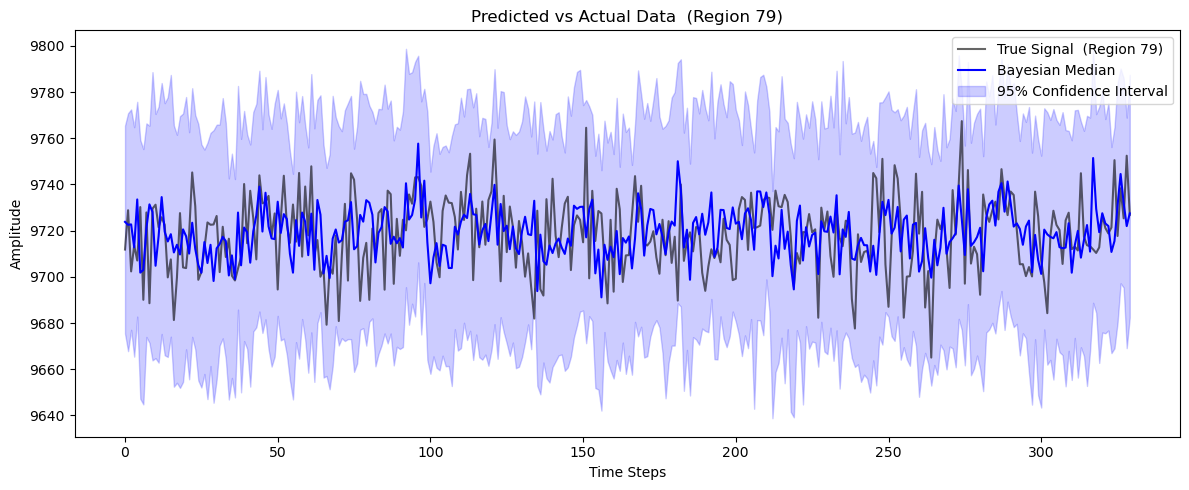

In [11]:
# PREDICT & PLOT
scaler = {'mean': train_ds.mean, 'std': train_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, valid_ds, num_samples = 100, scaler = scaler, 
                                                           region_idx = 79)

Compute the metrics to evaluate the results

In [12]:
ecov, cal, mcrps = evaluate_metrics(y_pred_samples=y_samples, y_true = y_true)

In [13]:
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values
n_mcrps_per_region = mcrps / ranges

In order to have a baseline for the mean CRPS, we normalize with respect to the interval of the time series

In [14]:
n_mcrps_per_region.mean().item() * 100

10.158253461122513

## Random search

We now want to try to optimize the architecture by tuning the hyperparameters of the system, in particular we vary:
- Spectral radius of $W$
- Number of neurons
- Reservoir's activation function
- Adam's learning rate
- Sampled weights variance

In [15]:
# parameters space
spectral_radius_list = [0.1,0.3,0.5,0.7,0.9,1.1]
neurons_list = [16, 32, 64, 128, 256, 512]
activations_list = [nn.ReLU(), nn.Tanh()] 
learning_rates = [0.0001, 0.001, 0.01]
scales = [0.01, 0.1, 1.0]

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values
      

In [16]:
num_iterations = 20
results = []

for i in range(num_iterations):
    # Clear Pyro's parameter store to prevent memory leaks across trials
    pyro.clear_param_store()
    
    # Sample hyperparameters randomly for this trial
    n = random.choice(neurons_list)
    act_name = random.choice(activations_list)
    lr = random.choice(learning_rates)
    s = random.choice(scales)
    spectral_radius = random.choice(spectral_radius_list)
    
    print(f"\n--- Trial {i+1}/{num_iterations} ---")
    print(f"Parameters: Neurons={n}, Activation={act_name}, LR={lr}, Scale={s}, Spectral radius={spectral_radius}")

    try:
        # Setup Optimizer and Pyro Guide
        optimizer = pyro.optim.Adam({"lr": lr})
        
        RANK = int(np.sqrt(n))  # Rank for the Multivariate Normal
        guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

        # Instantiate the Bayesian ESN model
        esn_var = ESNVariational(
            N=n, 
            K=INPUT_DIM, 
            pyro_model=model_fn, 
            pyro_guide=guide, 
            optimizer=optimizer,
            spectral_radius=spectral_radius,
            scale=s
        )
        
        esn_var.reservoir.activation = act_name 

        # Construct dataset and DataLoader for this specific reservoir state
        train_ds, valid_ds = construct_dataset(esn_var.reservoir, data.T, train_split=0.7)
        current_train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)

        # Train the model
        esn_var.train(current_train_loader, epochs=100)

        # Disable gradient tracking to save massive amounts of RAM during inference
        with torch.no_grad():
            scaler = {'mean': train_ds.mean, 'std': train_ds.std}
            
            # Get predictions
            y_true_eval, y_samples_eval, *_ = prediction_curve(esn_var, valid_ds, scaler = scaler, plot=False, num_samples = 1000)
            
            # Detach tensors from the computational graph to ensure they don't hold memory
            if isinstance(y_true_eval, torch.Tensor):
                y_true_eval = y_true_eval.detach()
            if isinstance(y_samples_eval, torch.Tensor):
                y_samples_eval = y_samples_eval.detach()
            
            # Calculate metrics
            ecov, cal, mcrps = evaluate_metrics(y_samples_eval, y_true_eval)

            # Convert the vector of mCRPS into a normalized average
            n_mcrps = mcrps / ranges
            avg_mcrps = n_mcrps.mean().item()

        results.append({
            'neurons': n,
            'activation': act_name,
            'lr': lr,
            'spectral_radius': spectral_radius,
            'scale': s,
            'ecov': ecov,
            'cal': cal,
            'avg_mcrps': avg_mcrps
        })

        # Delete heavy objects created in this iteration
        del esn_var
        del guide
        del optimizer
        del train_ds
        del valid_ds
        del current_train_loader
        del y_true_eval
        del y_samples_eval
        del scaler
        
        # Force Python's Garbage Collector to free the unreferenced memory immediately
        gc.collect()
        
    except Exception as e:
        print(f"Error at iteration {i+1}: {e}")
        # Ensure cleanup even if an error occurs to prevent cascading Out-Of-Memory errors
        gc.collect()


--- Trial 1/20 ---
Parameters: Neurons=256, Activation=ReLU(), LR=0.01, Scale=0.1, Spectral radius=0.9


Training Pyro ESN:   1%|          | 1/100 [00:00<01:08,  1.45it/s, Loss=10865287.3807]

Epoch 0 | Total ELBO Loss: 10865287.3807


Training Pyro ESN: 100%|██████████| 100/100 [01:11<00:00,  1.39it/s, Loss=9547.7608]  



--- Trial 2/20 ---
Parameters: Neurons=32, Activation=ReLU(), LR=0.0001, Scale=1.0, Spectral radius=0.5


...

Training Pyro ESN: 100%|██████████| 100/100 [00:29<00:00,  3.43it/s, Loss=306.1490]



--- Trial 20/20 ---
Parameters: Neurons=128, Activation=ReLU(), LR=0.01, Scale=0.1, Spectral radius=0.3


Training Pyro ESN:   1%|          | 1/100 [00:00<00:46,  2.15it/s, Loss=6454531.8265]

Epoch 0 | Total ELBO Loss: 6454531.8265


Training Pyro ESN: 100%|██████████| 100/100 [00:46<00:00,  2.16it/s, Loss=5540.1259] 


In [17]:
df_results = pd.DataFrame(results)
df_results['ecov_dist'] = (df_results['ecov'] - 0.95).abs()

# Order the results
best_models = df_results.sort_values(by=['cal', 'ecov_dist', 'avg_mcrps'])

print(best_models.head(5))


    neurons activation     lr  spectral_radius  scale      ecov       cal  \
16       64     ReLU()  0.010              0.5   0.01  0.963196  0.000322   
2        32     ReLU()  0.001              1.1   0.01  0.974522  0.000322   
11      256     ReLU()  0.001              0.9   0.01  0.918597  0.000494   
7        32     ReLU()  0.001              0.1   0.10  0.983193  0.000945   
17       32     ReLU()  0.010              1.1   0.01  0.994081  0.001211   

    avg_mcrps  ecov_dist  
16   0.091865   0.013196  
2    0.283090   0.024522  
11   0.666643   0.031403  
7    0.091904   0.033193  
17   0.122470   0.044081  


In [18]:
best_models.iloc[0,:]

neurons                  64
activation           ReLU()
lr                     0.01
spectral_radius         0.5
scale                  0.01
ecov               0.963196
cal                0.000322
avg_mcrps          0.091865
ecov_dist          0.013196
Name: 16, dtype: object

## Best model

In [19]:
best_params = best_models.iloc[0,:]
best_params

neurons                  64
activation           ReLU()
lr                     0.01
spectral_radius         0.5
scale                  0.01
ecov               0.963196
cal                0.000322
avg_mcrps          0.091865
ecov_dist          0.013196
Name: 16, dtype: object

In [20]:
pyro.clear_param_store()

In [21]:
# PARAMETERS

N_NEURONS = best_params['neurons']
INPUT_DIM = data.shape[0] # equals to output dim

LR = best_params['lr']
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": LR})

In [22]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 119), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [23]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

In [24]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius = best_params['spectral_radius'],
    scale = best_params['scale']
)


In [25]:
esn_var.reservoir.activation = act_name

In [26]:
train_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

In [27]:
# retrain on the full first dataset
history = esn_var.train(train_loader, EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:00<01:33,  1.06it/s, Loss=80069466.7181]

Epoch 0 | Total ELBO Loss: 80069466.7181


Training Pyro ESN: 100%|██████████| 100/100 [00:54<00:00,  1.85it/s, Loss=18156.7834] 


In [28]:
# fetch test dataset
data_test = torch.from_numpy(sio.loadmat('100307.REST2.LR.SchaeferS.ptseries.mat')['tseries']).float()

In [29]:
# Generate Torch datasets
test_ds, _ = construct_dataset(esn_var.reservoir, data.T, train_split=1.0, burnin=100)

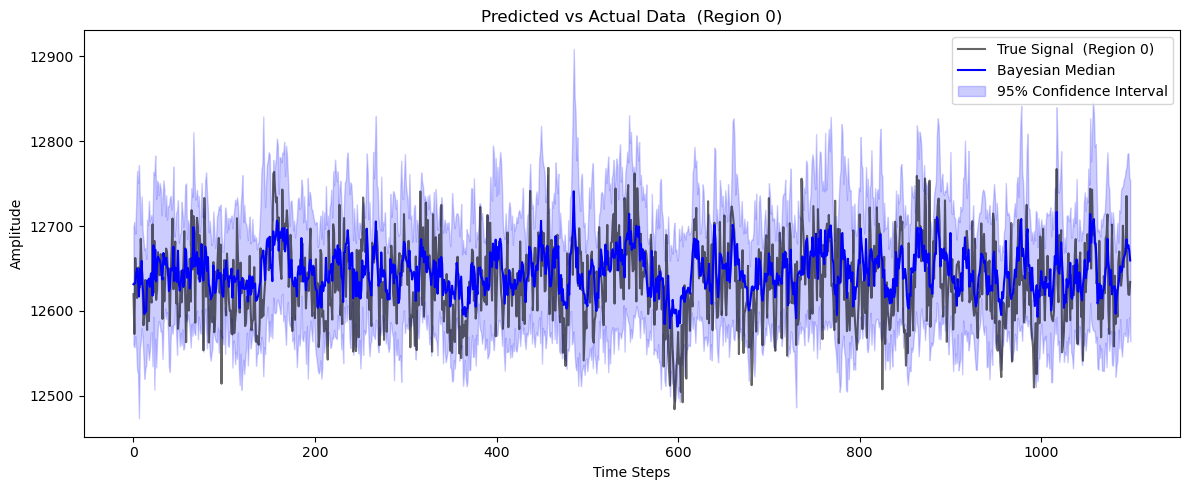

In [30]:
# predict
scaler = {"mean": test_ds.mean, "std": test_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000)

In [31]:
# metrics
ecov, cal, mcrps = evaluate_metrics(y_samples, y_true)

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values


# convert the vector of mrcps in a normalized avergae
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()

In [32]:
print(ecov, cal, avg_mcrps)

0.9366421699523926 0.00019381741398816964 0.07330876588821411


## Visualizations

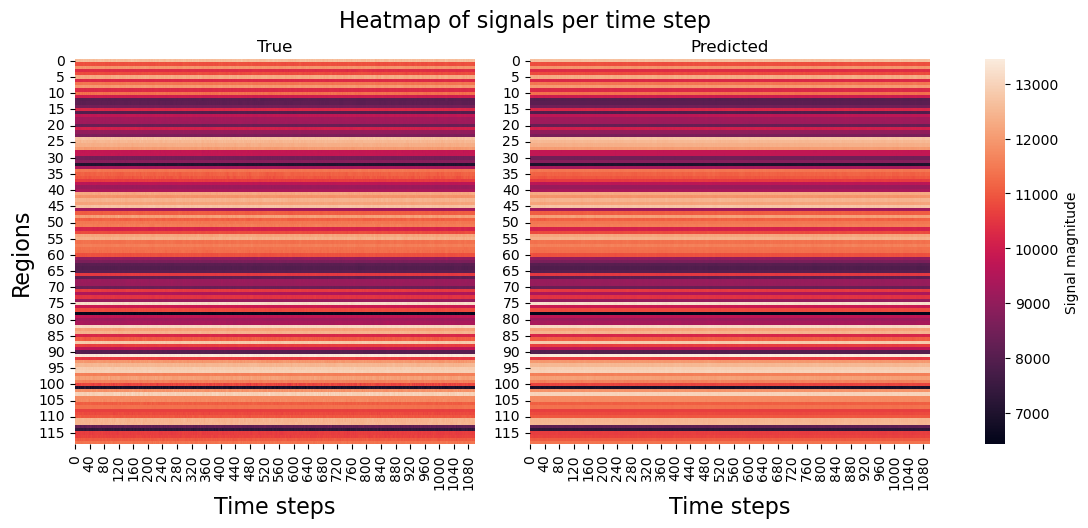

In [33]:
fig, ax = plt.subplots(1,3, figsize = (12,5), gridspec_kw={'width_ratios': [1, 1, 0.05]})
fig.suptitle('Heatmap of signals per time step', fontsize = 16)


ax[0].set_title('True')
# Set the labels
sns.heatmap(y_true.T, cbar = False, ax=ax[0])
ax[0].set_xlabel("Time steps", fontsize=16)
ax[0].set_ylabel("Regions", fontsize=16)



sns.heatmap(y_mean.T,  cbar_kws={'label': 'Signal magnitude'}, ax = ax[1], cbar_ax= ax[2])

# Set the labels
ax[1].set_title('Predicted')
ax[1].set_xlabel("Time steps", fontsize=16)
#ax[1].set_ylabel("Regions", fontsize=16)

plt.show()


## heatmap mCRPS

In [34]:
num_samples = y_samples.shape[0]
    
# quantiles grid
tau_grid = torch.linspace(0.0, 1.0, 101)


# shape: [101, Time, Regions]
q = torch.quantile(y_samples, tau_grid, dim=0)


# y_true_extended has shape [1, Time, Regions] for broadcasting
y_true_extended = y_true.unsqueeze(0)
errors = y_true_extended - q  # [101, Time, Regions]

# Pinball Loss
# tau_grid_extended has shape [101, 1, 1] --> done for broadcasting
tau_grid_extended = tau_grid.view(-1, 1, 1)
loss = torch.max(tau_grid_extended * errors, (tau_grid_extended - 1) * errors)

In [35]:
data_heatmap = loss.mean(dim=0).T
ranges_extended = ranges.repeat(data_heatmap.shape[1],1).T
data_heatmap = (data_heatmap/ranges_extended) * 100

Text(170.72222222222223, 0.5, 'Regions')

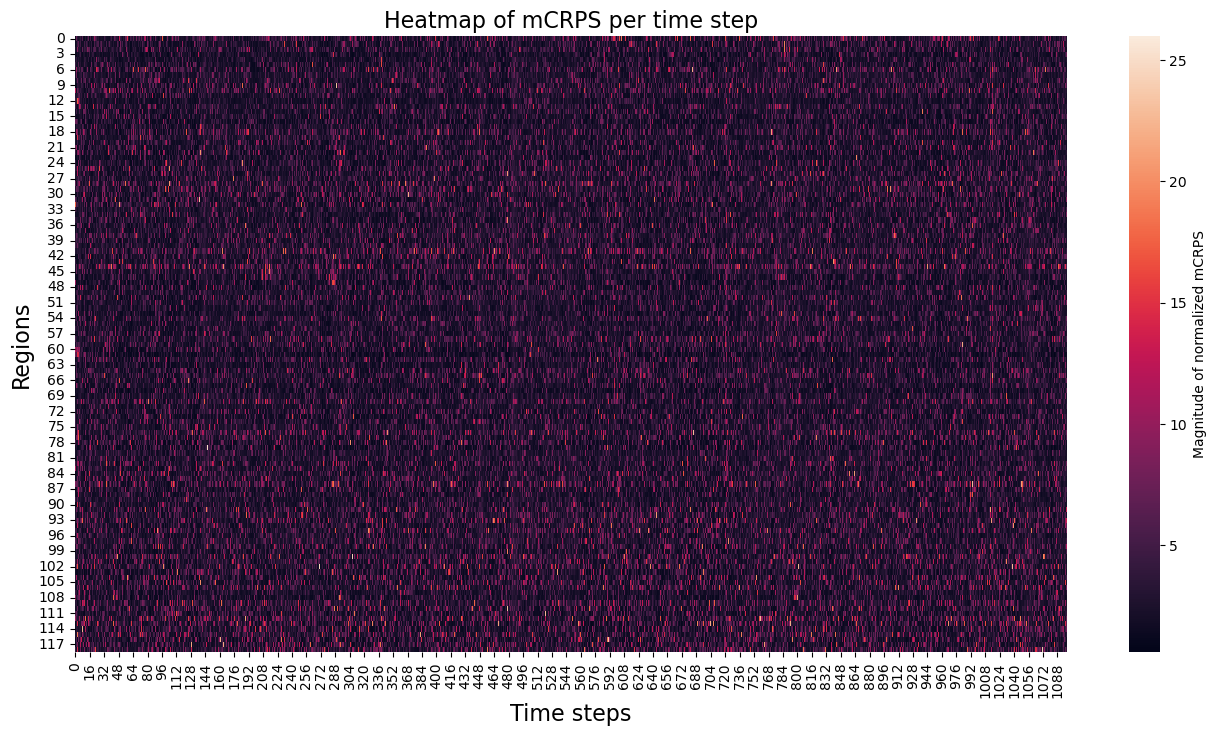

In [36]:
plt.figure(figsize=(16,8))
plt.title('Heatmap of mCRPS per time step', fontsize = 16)

ax = sns.heatmap(data_heatmap, cbar_kws={'label': 'Magnitude of normalized mCRPS'})
ax.set_xlabel("Time steps", fontsize=16)
ax.set_ylabel("Regions", fontsize=16)